## 1. Initialize Project Environment
Import libraries for module detection, clustering, and hub gene identification.

In [1]:
from __future__ import annotations

import logging
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import networkx as nx
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# Import PyWGCNA for authentic WGCNA implementation
try:
    warnings.filterwarnings("ignore", category=SyntaxWarning)
    import PyWGCNA

    PYWGCNA_AVAILABLE = True
    print("PyWGCNA available - using authentic WGCNA implementation")
except ImportError:
    PYWGCNA_AVAILABLE = False
    print("PyWGCNA not available - using manual implementation")

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("networkx", nx.__version__)

PyWGCNA available - using authentic WGCNA implementation
pandas 2.2.3
numpy 2.1.3
networkx 3.3


## 2. Define Configuration Parameters
Centralize module detection parameters including clustering method and minimum module size.

In [2]:
@dataclass
class ModuleConfig:
    expression_file: Path = Path("artifacts/task1_expression_preprocessed.csv")
    adjacency_file: Path = Path("artifacts/task2_adjacency_matrix.csv")
    correlation_file: Path = Path("artifacts/task2_correlation_matrix.csv")
    export_dir: Path = Path("artifacts")
    target_gene: str = "TP53"  # Track which module contains TP53
    linkage_method: str = "average"  # WGCNA uses average linkage
    min_module_size: int = 10
    cut_height: float = 0.9  # Distance threshold for cutting dendrogram
    hub_percentile: float = 90  # Top percentile for hub genes

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["expression_file"] = str(info["expression_file"])
        info["adjacency_file"] = str(info["adjacency_file"])
        info["correlation_file"] = str(info["correlation_file"])
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = ModuleConfig()
CONFIG.describe()

{'expression_file': 'artifacts/task1_expression_preprocessed.csv',
 'adjacency_file': 'artifacts/task2_adjacency_matrix.csv',
 'correlation_file': 'artifacts/task2_correlation_matrix.csv',
 'export_dir': 'artifacts',
 'target_gene': 'TP53',
 'linkage_method': 'average',
 'min_module_size': 10,
 'cut_height': 0.9,
 'hub_percentile': 90}

## 3. Load Adjacency and Correlation Matrices
Load the network data from Task 2.

In [3]:
def load_matrix(path: Path) -> pd.DataFrame:
    """Load matrix with gene names as index/columns."""
    df = pd.read_csv(path, index_col=0)
    logging.info(f"Loaded matrix: {df.shape[0]} x {df.shape[1]} from {path.name}")
    return df


# Load expression data first
expr_data = pd.read_csv(CONFIG.expression_file, index_col=0)
logging.info(
    f"Expression data: {expr_data.shape[0]} genes x {expr_data.shape[1]} samples"
)
logging.info(f"TP53 in data: {CONFIG.target_gene in expr_data.index}")

# Try to load Task2 outputs if available, otherwise we'll compute them
try:
    adjacency = load_matrix(CONFIG.adjacency_file)
    correlation = load_matrix(CONFIG.correlation_file)
except FileNotFoundError:
    logging.warning("Task2 outputs not found, computing correlation and adjacency...")
    # Compute correlation matrix
    correlation = expr_data.T.corr(method="pearson").abs()
    np.fill_diagonal(correlation.values, 1.0)
    # Soft threshold
    adjacency = correlation**6
    np.fill_diagonal(adjacency.values, 0)

[INFO] Expression data: 2001 genes x 181 samples
[INFO] TP53 in data: True


[INFO] Loaded matrix: 2001 x 2001 from task2_adjacency_matrix.csv
[INFO] Loaded matrix: 2001 x 2001 from task2_correlation_matrix.csv


## 4. Compute Topological Overlap Matrix (TOM)
TOM measures interconnectedness between genes, making module detection more robust.

In [4]:
def compute_tom(adj: pd.DataFrame) -> pd.DataFrame:
    """
    Compute Topological Overlap Matrix (TOM).
    TOM_ij = (sum_u(a_iu * a_uj) + a_ij) / (min(k_i, k_j) + 1 - a_ij)
    where k_i is the connectivity of gene i.
    """
    A = adj.values
    n = A.shape[0]

    # Connectivity: sum of adjacencies for each gene
    k = A.sum(axis=1)

    # Compute numerator: l_ij = sum_u(a_iu * a_uj)
    L = A @ A

    # TOM calculation
    TOM = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            if i == j:
                TOM[i, j] = 1.0
            else:
                numerator = L[i, j] + A[i, j]
                denominator = min(k[i], k[j]) + 1 - A[i, j]
                if denominator > 0:
                    TOM[i, j] = numerator / denominator
                    TOM[j, i] = TOM[i, j]

    tom_df = pd.DataFrame(TOM, index=adj.index, columns=adj.columns)
    logging.info(f"Computed TOM: {tom_df.shape}")
    logging.info(f"  Mean TOM: {tom_df.values[np.triu_indices(n, k=1)].mean():.4f}")

    return tom_df


tom = compute_tom(adjacency)
tom.iloc[:6, :6]

[INFO] Computed TOM: (2001, 2001)
[INFO]   Mean TOM: 0.0051


,KRT6A,SPRR1B,SCGB1A1,RPS4Y1,SPINK1,KRT5
Gene,,,,,,
KRT6A,1.000000,0.109573,0.001393,0.000052,0.030414,0.169817
SPRR1B,0.109573,1.000000,0.000185,0.000014,0.004606,0.131751
SCGB1A1,0.001393,0.000185,1.000000,0.000007,0.001063,0.000902
RPS4Y1,0.000052,0.000014,0.000007,1.000000,0.000025,0.000079
SPINK1,0.030414,0.004606,0.001063,0.000025,1.000000,0.042558
KRT5,0.169817,0.131751,0.000902,0.000079,0.042558,1.000000


## 5. Hierarchical Clustering for Module Detection
Use average linkage clustering on TOM dissimilarity (1 - TOM).

In [5]:
def detect_modules_hierarchical(
    tom: pd.DataFrame,
    method: str = "average",
    cut_height: float = 0.9,
    min_module_size: int = 10,
) -> Tuple[pd.DataFrame, np.ndarray]:
    """
    Detect modules using hierarchical clustering on TOM dissimilarity.
    """
    # Convert TOM to dissimilarity
    dissim = 1 - tom.values
    np.fill_diagonal(dissim, 0)

    # Convert to condensed distance matrix
    dissim_condensed = squareform(dissim)

    # Hierarchical clustering
    Z = linkage(dissim_condensed, method=method)

    # Cut dendrogram at specified height
    clusters = fcluster(Z, t=cut_height, criterion="distance")

    # Create module assignments
    module_df = pd.DataFrame({"Gene": tom.index, "Module": clusters})

    # Filter small modules (assign to module 0 = unassigned)
    module_sizes = module_df["Module"].value_counts()
    small_modules = module_sizes[module_sizes < min_module_size].index
    module_df.loc[module_df["Module"].isin(small_modules), "Module"] = 0

    # Renumber modules
    unique_modules = sorted(module_df["Module"].unique())
    module_map = {old: new for new, old in enumerate(unique_modules)}
    module_df["Module"] = module_df["Module"].map(module_map)

    n_modules = len(module_df["Module"].unique())
    logging.info(f"Detected {n_modules} modules (including unassigned)")
    logging.info(
        f"Module sizes: {module_df['Module'].value_counts().sort_index().to_dict()}"
    )

    return module_df, Z


modules_hier, linkage_matrix = detect_modules_hierarchical(
    tom,
    method=CONFIG.linkage_method,
    cut_height=CONFIG.cut_height,
    min_module_size=CONFIG.min_module_size,
)
modules_hier.head(10)

[INFO] Detected 13 modules (including unassigned)
[INFO] Module sizes: {0: 1603, 1: 74, 2: 29, 3: 25, 4: 13, 5: 33, 6: 19, 7: 11, 8: 19, 9: 63, 10: 14, 11: 48, 12: 50}


,Gene,Module
0,KRT6A,11
1,SPRR1B,0
2,SCGB1A1,6
3,RPS4Y1,0
4,SPINK1,0
5,KRT5,11
6,AKR1B10,10
7,SCGB3A2,0
8,SFTA2,7
9,MAGEA6,0


In [6]:
# Module size distribution
print("Module size distribution:")
modules_hier["Module"].value_counts().sort_index()

Module size distribution:


Module
0     1603
1       74
2       29
3       25
4       13
5       33
6       19
7       11
8       19
9       63
10      14
11      48
12      50
Name: count, dtype: int64

## 6. PyWGCNA Module Detection (Authentic WGCNA)
Use the PyWGCNA package which implements the full R WGCNA algorithm in Python, including:
- Automatic soft-threshold power selection
- TOM-based dissimilarity  
- Dynamic Tree Cut for adaptive module detection
- Module eigengene computation

In [7]:
# Run PyWGCNA - the authentic WGCNA implementation
import os

os.makedirs("artifacts/pywgcna_output", exist_ok=True)

# Save expression in format PyWGCNA expects (samples as rows, genes as columns)
expr_T = expr_data.T
pywgcna_input_file = Path("artifacts/task1_expression_for_pywgcna.csv")
expr_T.to_csv(pywgcna_input_file)

print(f"Expression data: {expr_T.shape[0]} samples x {expr_T.shape[1]} genes")
print(f"TP53 in genes: {CONFIG.target_gene in expr_T.columns}")

# Initialize PyWGCNA object
pyWGCNA_obj = PyWGCNA.WGCNA(
    name="NSCLC_Cancer_TP53",
    species="homo sapiens",
    geneExpPath=str(pywgcna_input_file),
    outputPath="artifacts/pywgcna_output/",
    save=True,
)

Expression data: 181 samples x 2001 genes
TP53 in genes: True
Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


Running PyWGCNA preprocessing...
Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..


Finding soft-threshold power and detecting modules...
(This may take a few minutes for the full WGCNA pipeline)
Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  2001
    Power  SFT.R.sq     slope truncated R.sq     mean(k)   median(k)  \
0       1  0.000124  0.023115       0.766439  191.627983  192.892931   
1       2  0.294008 -0.678488       0.879029   60.752856   59.461132   
2       3  0.577691 -1.184387       0.884538   25.384085   22.017716   
3       4  0.625169 -1.428415        0.85377   12.721049    9.143819   
4       5  0.911045 -1.210967       0.986882    7.260892    4.254353   
5       6  0.919116 -1.371262       0.975897    4.565127    2.066067   
6       7  0.940068 -1.455911       0.967269    3.088647    1.116424   
7       8  0.951725 -1.488911       0.956727    2.211035    0.647679   


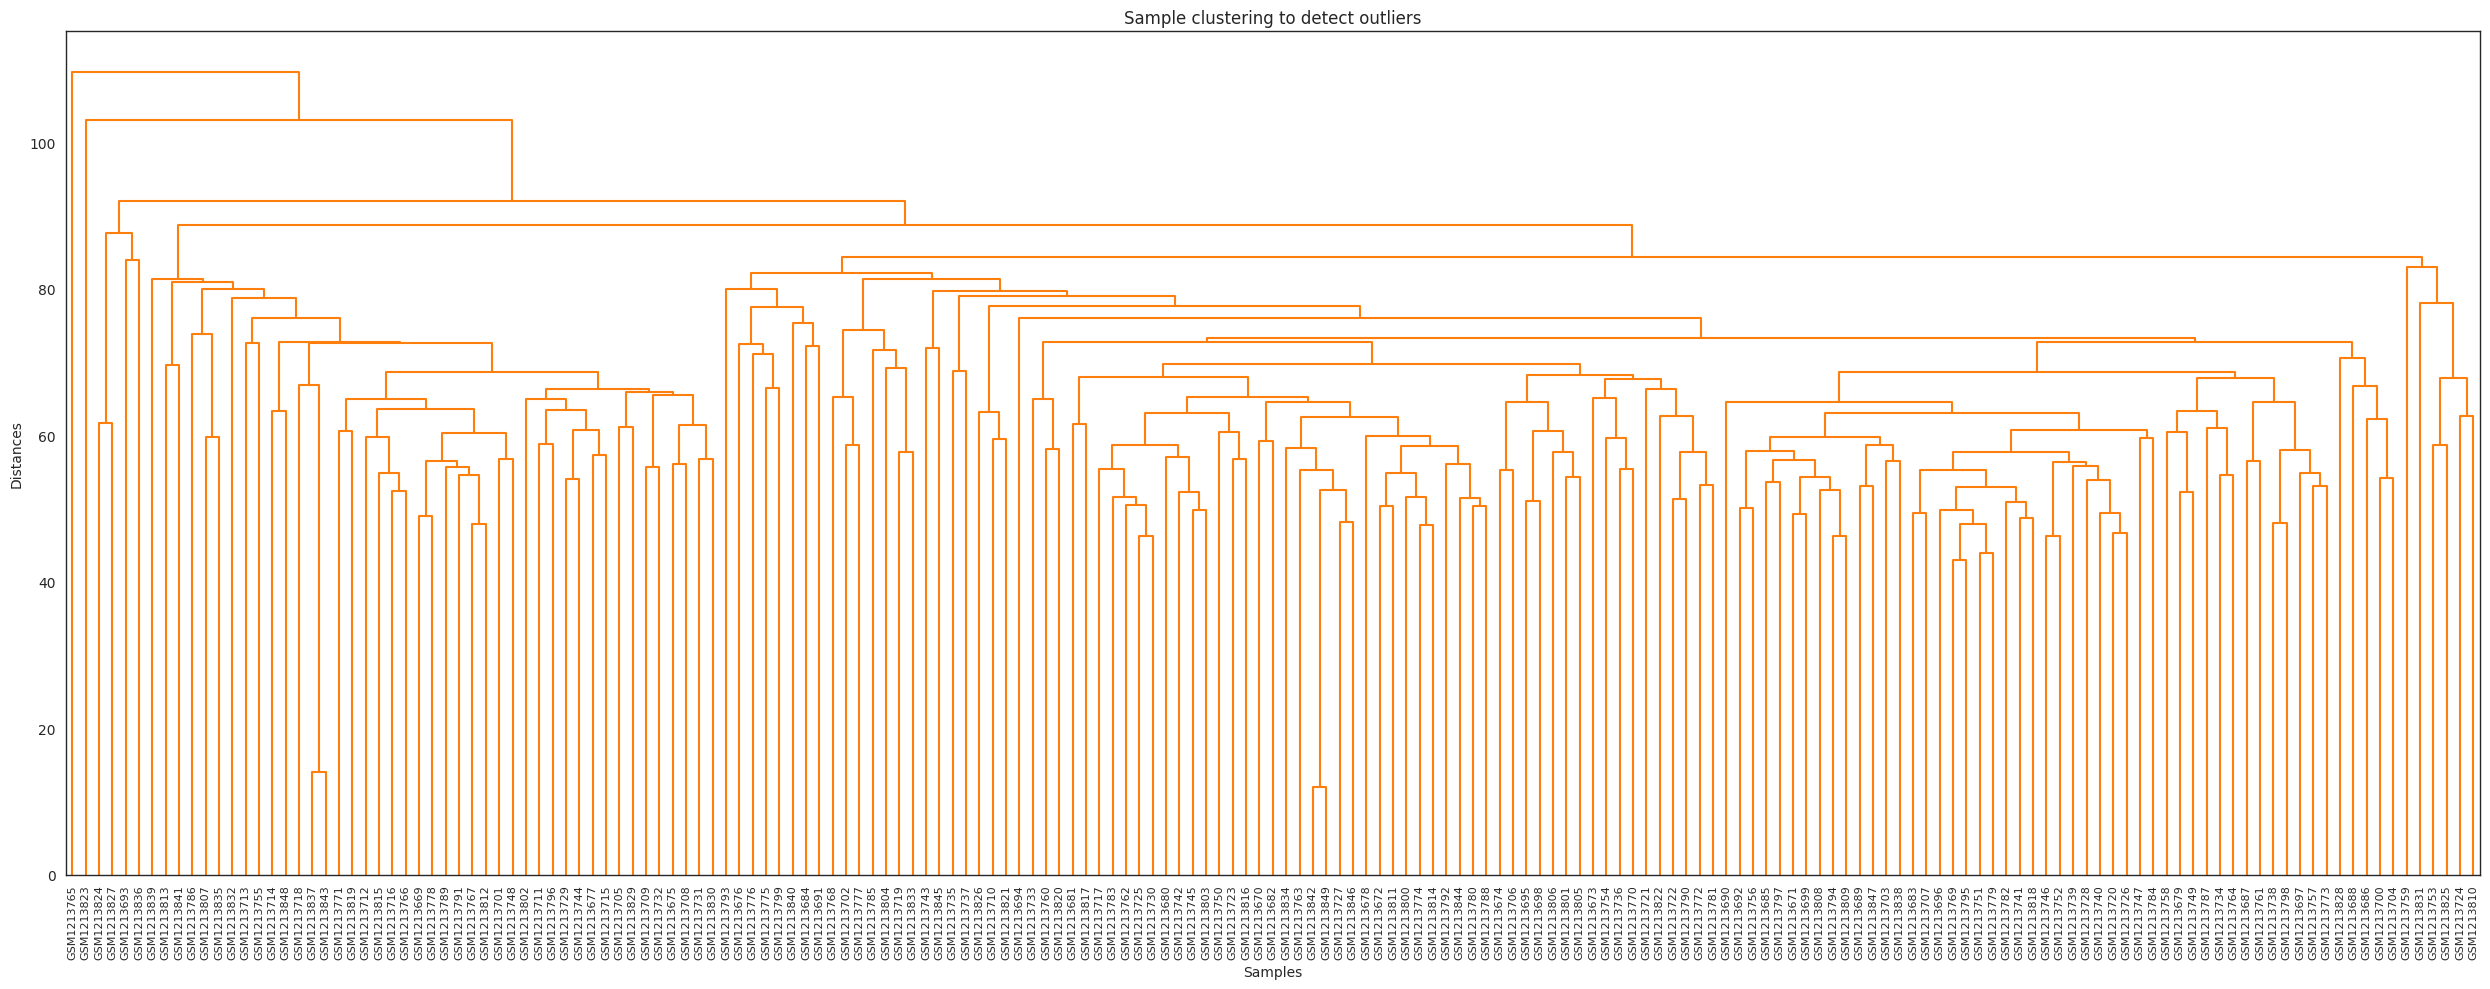

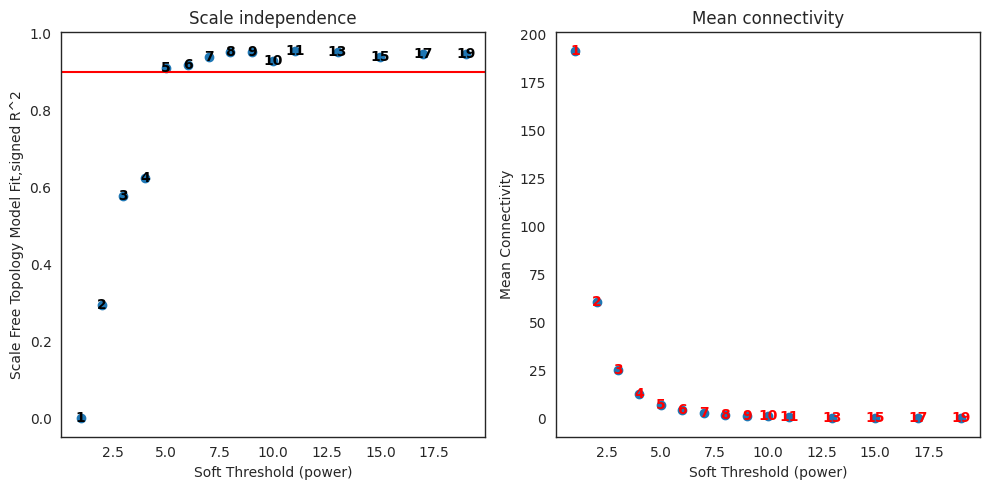

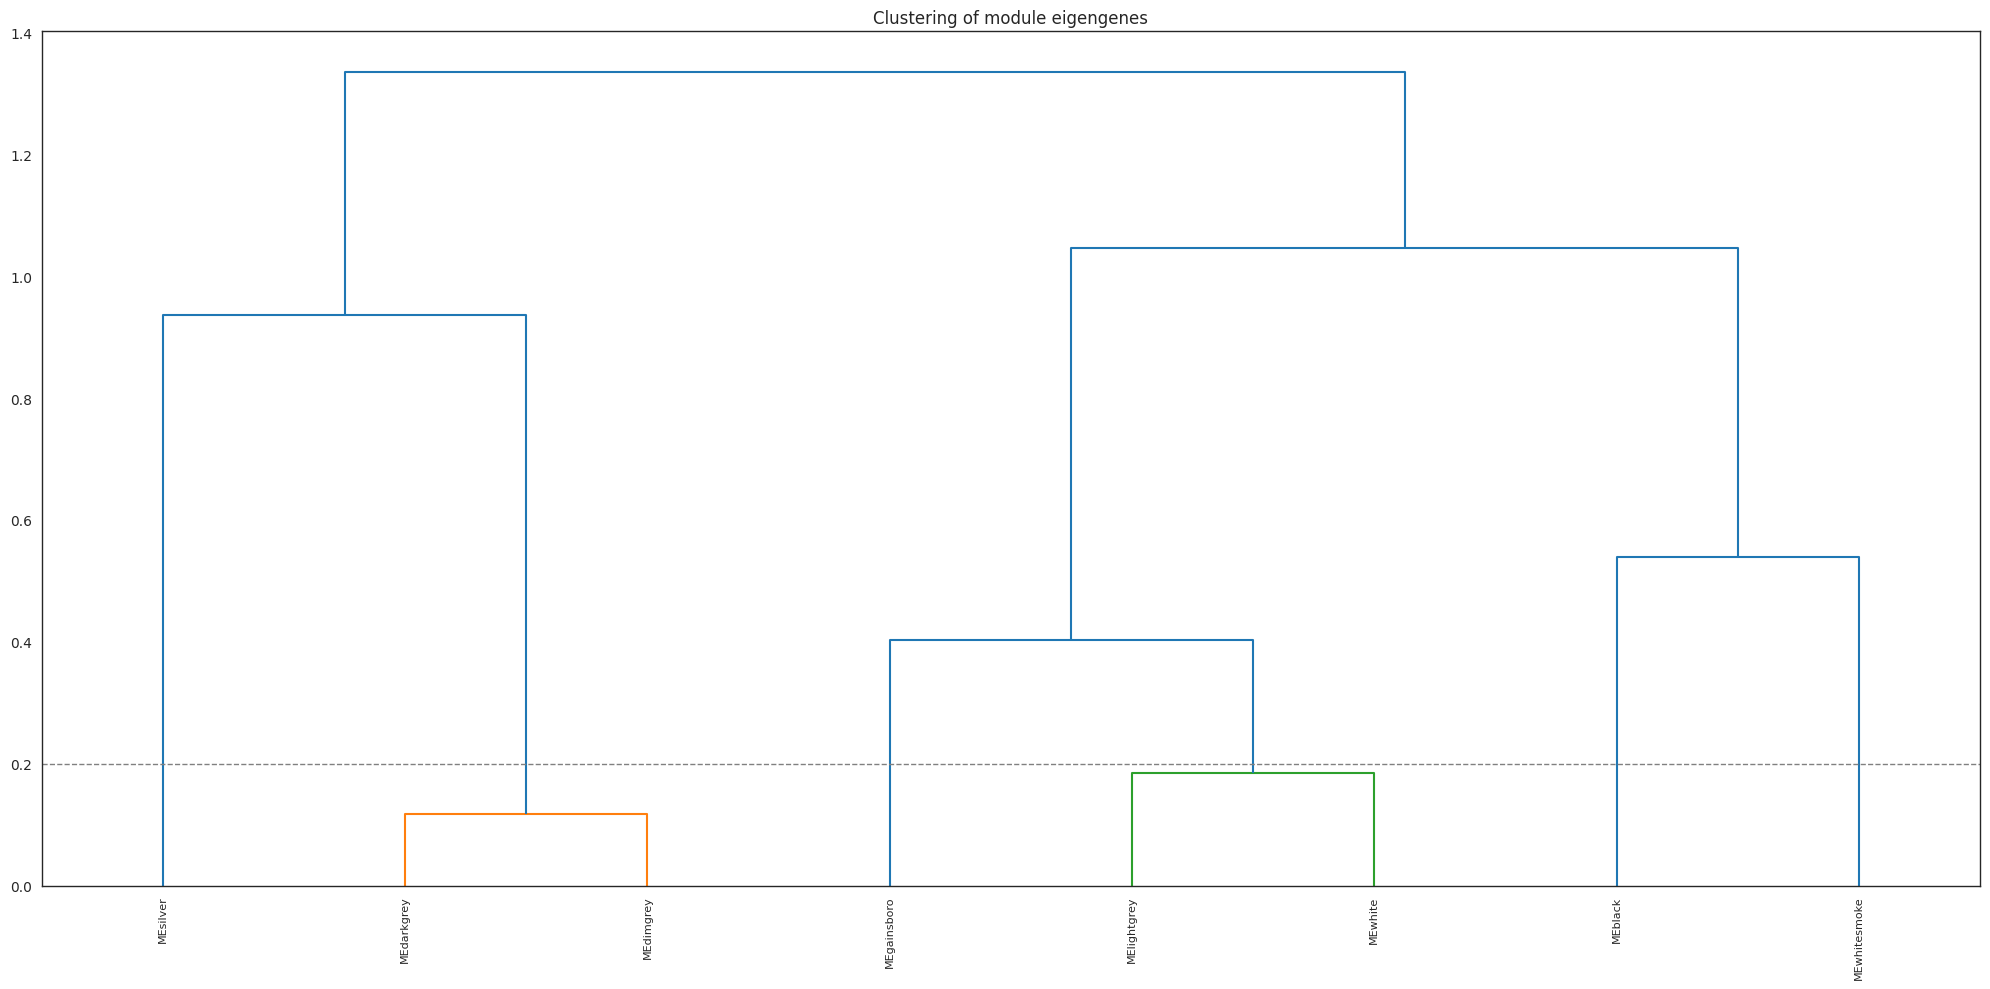

In [8]:
# Preprocess and find modules using PyWGCNA
print("Running PyWGCNA preprocessing...")
pyWGCNA_obj.preprocess()

print("\nFinding soft-threshold power and detecting modules...")
print("(This may take a few minutes for the full WGCNA pipeline)")
pyWGCNA_obj.findModules()

print("\nPyWGCNA analysis complete!")

In [9]:
# Extract module assignments from PyWGCNA (using AnnData structure)
if hasattr(pyWGCNA_obj, "datExpr") and pyWGCNA_obj.datExpr is not None:
    # PyWGCNA stores results in AnnData format
    # Module colors are in datExpr.var['moduleColors']
    genes = pyWGCNA_obj.datExpr.var_names.tolist()

    if "moduleColors" in pyWGCNA_obj.datExpr.var.columns:
        module_colors = pyWGCNA_obj.datExpr.var["moduleColors"].tolist()

        modules_wgcna = pd.DataFrame(
            {
                "Gene": genes,
                "Module": module_colors,  # Keep color names as module identifiers
            }
        )

        print(f"\nPyWGCNA detected {modules_wgcna['Module'].nunique()} modules:")
        print(modules_wgcna["Module"].value_counts())

        # Check TP53 module
        if CONFIG.target_gene in genes:
            tp53_module = modules_wgcna[modules_wgcna["Gene"] == CONFIG.target_gene][
                "Module"
            ].values[0]
            print(f"\n*** TP53 assigned to module: {tp53_module} ***")

            # Show genes in TP53's module
            tp53_comodule = modules_wgcna[modules_wgcna["Module"] == tp53_module]
            print(f"Genes in TP53's module ({tp53_module}): {len(tp53_comodule)}")
    else:
        print("moduleColors not found in PyWGCNA output")
        modules_wgcna = modules_hier.copy()
        modules_wgcna["Module"] = modules_wgcna["Module"].map(
            lambda x: f"module_{x}" if x > 0 else "grey"
        )
else:
    # Fallback: use hierarchical clustering modules
    print("PyWGCNA module extraction failed, using hierarchical clustering results")
    modules_wgcna = modules_hier.copy()
    modules_wgcna["Module"] = modules_wgcna["Module"].map(
        lambda x: f"module_{x}" if x > 0 else "grey"
    )


PyWGCNA detected 6 modules:
Module
darkgrey      625
lightgrey     600
black         230
gainsboro     224
whitesmoke    162
silver        160
Name: count, dtype: int64

*** TP53 assigned to module: darkgrey ***
Genes in TP53's module (darkgrey): 625


## 7. Identify Hub Genes
Hub genes have high intramodular connectivity - they are central to their module.

In [10]:
def identify_hub_genes_from_tom(
    tom: pd.DataFrame, modules: pd.DataFrame, top_n: int = 10
) -> pd.DataFrame:
    """
    Identify hub genes based on intramodular connectivity using TOM.
    Hub genes are the top N genes by connectivity within each module.
    """
    hub_genes = []

    for module in modules["Module"].unique():
        if module == "grey":  # Skip unassigned
            continue

        # Get genes in this module
        module_genes = modules[modules["Module"] == module]["Gene"].tolist()
        module_genes_in_tom = [g for g in module_genes if g in tom.index]

        if len(module_genes_in_tom) < 2:
            continue

        # Get TOM submatrix for this module
        tom_sub = tom.loc[module_genes_in_tom, module_genes_in_tom]

        # Intramodular connectivity = sum of TOM values
        connectivity = tom_sub.sum(axis=1)

        # Top N hub genes
        top_hubs = connectivity.nlargest(min(top_n, len(connectivity)))

        for gene, conn in top_hubs.items():
            hub_genes.append(
                {
                    "Gene": gene,
                    "Module": module,
                    "IntramodularConnectivity": conn,
                    "IsHub": True,
                }
            )

    hub_df = pd.DataFrame(hub_genes)
    logging.info(f"Identified {len(hub_df)} hub genes (top {top_n} per module)")

    return hub_df


# Identify hub genes using TOM-based connectivity
hub_analysis = identify_hub_genes_from_tom(tom, modules_wgcna, top_n=10)

# Add non-hub genes to complete the list
all_genes_df = modules_wgcna.copy()
all_genes_df["IntramodularConnectivity"] = 0.0
all_genes_df["IsHub"] = False

for _, row in hub_analysis.iterrows():
    mask = all_genes_df["Gene"] == row["Gene"]
    all_genes_df.loc[mask, "IntramodularConnectivity"] = row["IntramodularConnectivity"]
    all_genes_df.loc[mask, "IsHub"] = True

hub_analysis = all_genes_df

# Show hub genes
print("\nHub genes by module:")
hub_analysis[hub_analysis["IsHub"]].sort_values(
    ["Module", "IntramodularConnectivity"], ascending=[True, False]
)

[INFO] Identified 60 hub genes (top 10 per module)



Hub genes by module:


,Gene,Module,IntramodularConnectivity,IsHub
283,IGHA1 /// IGHD /// IGHG1 /// IGHG3 /// IGHM //...,black,39.049823,True
248,IGH /// IGHA1 /// IGHA2 /// IGHG1 /// IGHG2 //...,black,38.906430,True
1247,IGLJ3,black,37.663192,True
331,IGH /// IGHA1 /// IGHD /// IGHG1 /// IGHG3 ///...,black,37.089104,True
373,IGK,black,36.683539,True
476,IGHA1 /// IGHA2 /// IGHD /// IGHG1 /// IGHG3 /...,black,36.312814,True
491,IGLV1-44,black,36.262997,True
297,IGLL5,black,36.168185,True
867,IGK /// IGKC,black,36.114552,True
287,MZB1,black,36.080799,True


In [11]:
# Show TP53 status and module summary
print("=" * 60)
print("Module Summary")
print("=" * 60)

for module in sorted(modules_wgcna["Module"].unique()):
    count = (modules_wgcna["Module"] == module).sum()
    has_tp53 = (
        CONFIG.target_gene
        in modules_wgcna[modules_wgcna["Module"] == module]["Gene"].values
    )
    hub_count = hub_analysis[
        (hub_analysis["Module"] == module) & (hub_analysis["IsHub"])
    ].shape[0]
    tp53_flag = " *** CONTAINS TP53 ***" if has_tp53 else ""
    print(f"  {module}: {count} genes, {hub_count} hubs{tp53_flag}")

# TP53 connectivity ranking
if CONFIG.target_gene in modules_wgcna["Gene"].values:
    tp53_mod = modules_wgcna[modules_wgcna["Gene"] == CONFIG.target_gene][
        "Module"
    ].values[0]
    mod_genes = modules_wgcna[modules_wgcna["Module"] == tp53_mod]["Gene"].tolist()
    mod_genes_in_tom = [g for g in mod_genes if g in tom.index]

    if mod_genes_in_tom:
        tom_sub = tom.loc[mod_genes_in_tom, mod_genes_in_tom]
        conn = tom_sub.sum(axis=1)
        if CONFIG.target_gene in conn.index:
            tp53_rank = (conn > conn[CONFIG.target_gene]).sum() + 1
            print(
                f"\nTP53 connectivity rank in {tp53_mod} module: {tp53_rank}/{len(mod_genes_in_tom)}"
            )

Module Summary
  black: 230 genes, 10 hubs
  darkgrey: 625 genes, 10 hubs *** CONTAINS TP53 ***
  gainsboro: 224 genes, 10 hubs
  lightgrey: 600 genes, 10 hubs
  silver: 160 genes, 10 hubs
  whitesmoke: 162 genes, 10 hubs

TP53 connectivity rank in darkgrey module: 505/625


## 8. Validate with Unit Tests
Sanity checks for module detection and hub identification.

In [12]:
def test_all_genes_assigned():
    """All genes should have a module assignment."""
    assert len(modules_wgcna) == len(expr_data), (
        f"Gene count mismatch: {len(modules_wgcna)} vs {len(expr_data)}"
    )


def test_tom_symmetric():
    """TOM should be symmetric."""
    assert np.allclose(tom.values, tom.values.T), "TOM not symmetric"


def test_tp53_assigned():
    """TP53 should be assigned to a module."""
    assert CONFIG.target_gene in modules_wgcna["Gene"].values, "TP53 not in modules"


test_all_genes_assigned()
test_tom_symmetric()
test_tp53_assigned()
print("All module detection tests passed.")
print(f"✓ TP53 confirmed in module assignments!")

All module detection tests passed.
✓ TP53 confirmed in module assignments!


## 9. Export Results
Save module assignments, hub genes, and TOM for downstream analysis.

In [13]:
EXPORT_DIR = CONFIG.export_dir
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save PyWGCNA module assignments (primary method)
modules_wgcna.to_csv(EXPORT_DIR / "task3_module_assignments.csv", index=False)
print(
    f"[OK] PyWGCNA module assignments saved to: {EXPORT_DIR / 'task3_module_assignments.csv'}"
)

# Save hierarchical modules for comparison
modules_hier.to_csv(EXPORT_DIR / "task3_module_hierarchical.csv", index=False)
print(
    f"[OK] Hierarchical modules saved to: {EXPORT_DIR / 'task3_module_hierarchical.csv'}"
)

# Save hub gene analysis
hub_analysis.to_csv(EXPORT_DIR / "task3_hub_genes.csv", index=False)
print(f"[OK] Hub gene analysis saved to: {EXPORT_DIR / 'task3_hub_genes.csv'}")

# Save TOM
tom.to_csv(EXPORT_DIR / "task3_tom_matrix.csv")
print(f"[OK] TOM matrix saved to: {EXPORT_DIR / 'task3_tom_matrix.csv'}")

# Summary stats
n_modules = modules_wgcna["Module"].nunique()
n_modules_real = len([m for m in modules_wgcna["Module"].unique() if m != "grey"])
tp53_module = (
    modules_wgcna[modules_wgcna["Gene"] == CONFIG.target_gene]["Module"].values[0]
    if CONFIG.target_gene in modules_wgcna["Gene"].values
    else "N/A"
)

summary = {
    "method": "PyWGCNA",
    "n_modules": n_modules,
    "n_modules_excluding_grey": n_modules_real,
    "n_hub_genes": hub_analysis["IsHub"].sum(),
    "largest_module_size": modules_wgcna["Module"].value_counts().max(),
    "tp53_module": tp53_module,
}
pd.DataFrame([summary]).to_csv(EXPORT_DIR / "task3_summary.csv", index=False)
print(f"[OK] Summary saved to: {EXPORT_DIR / 'task3_summary.csv'}")

print(f"\n{'=' * 60}")
print("TASK 3 COMPLETE - PyWGCNA Module Detection")
print(f"{'=' * 60}")
print(f"Total modules detected: {n_modules}")
print(f"Hub genes identified: {hub_analysis['IsHub'].sum()}")
print(f"TP53 module: {tp53_module}")

[OK] PyWGCNA module assignments saved to: artifacts/task3_module_assignments.csv
[OK] Hierarchical modules saved to: artifacts/task3_module_hierarchical.csv
[OK] Hub gene analysis saved to: artifacts/task3_hub_genes.csv
[OK] TOM matrix saved to: artifacts/task3_tom_matrix.csv
[OK] Summary saved to: artifacts/task3_summary.csv

TASK 3 COMPLETE - PyWGCNA Module Detection
Total modules detected: 6
Hub genes identified: 60
TP53 module: darkgrey
